# 02 - SHAP Interpretability Analysis
This notebook focuses entirely on explaining the XGBoost models using SHAP (SHapley Additive exPlanations).
It provides both global and local interpretability for predicting ADHD outcomes and patient gender (Sex_F), strictly using the best hyperparameters found during Grid Search.

# 1. Mount Google Drive and Set Directory

In [28]:
from google.colab import drive
import os

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/ADHD-main'
os.chdir(project_path)

print(f"当前工作目录: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前工作目录: /content/drive/MyDrive/ADHD-main


In [37]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager, rcParams
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import json
import os
from matplotlib.lines import Line2D

rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['axes.unicode_minus'] = False


font_path = "data/Times New Roman.TTF"
if os.path.exists(font_path):
    font_manager.fontManager.addfont(font_path)
    rcParams["font.family"] = "Times New Roman"
else:
    print(f"Warning: 字体文件未找到 {font_path}，将使用系统默认新罗马字体。")
    rcParams['font.family'] = ['Times New Roman', 'DejaVu Sans', 'sans-serif']

plt.rcParams['axes.unicode_minus'] = False

## Section A: ADHD Outcome Prediction (SHAP)

### 2. Load Data for ADHD Prediction

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import json
import os

print("Loading data...")
# 在Colab中使用相对根目录的路径
cat_df = pd.read_csv("data/processed/cleaned_train_categorical_ohe.csv")
quant_df = pd.read_csv("data/processed/cleaned_train_quantitative.csv")
conn_df = pd.read_csv("data/processed/fMRI_ICA_100dim.csv")
labels_df = pd.read_csv("data/processed/cleaned_train_solutions.csv")

patient_ids = labels_df["participant_id"].tolist()

X_list = []
y_adhd_list = []

drop_cols_cat = ["participant_id", "Sex_F", "Basic_Demos_Enroll_Year"]
cat_feature_names = cat_df.drop(columns=drop_cols_cat, errors='ignore').columns.tolist()
quant_feature_names = quant_df.drop(columns=["participant_id"], errors='ignore').columns.tolist()
conn_feature_names = conn_df.drop(columns=["participant_id"], errors='ignore').columns.tolist()

clean_cat_names = [name.replace("__missing_ind", " (Missing)").replace("_", " ").replace("SDQ SDQ", "SDQ") for name in cat_feature_names]
clean_quant_names = [name.replace("__missing_ind", " (Missing)").replace("_", " ").replace("SDQ SDQ", "SDQ") for name in quant_feature_names]

feature_names = clean_cat_names + clean_quant_names + conn_feature_names

for pid in patient_ids:
    try:
        cat_data = cat_df[cat_df["participant_id"] == pid].drop(columns=drop_cols_cat, errors='ignore').values.flatten()
        quant_data = quant_df[quant_df["participant_id"] == pid].drop(columns=["participant_id"], errors='ignore').values.flatten()
        conn_data = conn_df[conn_df["participant_id"] == pid].drop(columns=["participant_id"], errors='ignore').values.flatten()

        if len(cat_data) == 0 or len(quant_data) == 0 or len(conn_data) == 0:
            continue

        combined_features = np.concatenate([cat_data, quant_data, conn_data])
        label1_val = labels_df[labels_df["participant_id"] == pid]["ADHD_Outcome"].values[0]

        X_list.append(combined_features)
        y_adhd_list.append(label1_val)
    except IndexError:
        continue

X_features_only = pd.DataFrame(X_list, columns=feature_names)
y_adhd = np.array(y_adhd_list)

X_train_adhd, X_test_adhd, y_train_adhd, y_test_adhd = train_test_split(
    X_features_only, y_adhd, test_size=0.3, random_state=42
)

print("Data loaded successfully! Feature names are now clean.")

Loading data...
Data loaded successfully! Feature names are now clean.


### 3. Train XGBoost Model (GridSearch Optimal Params)
注：shap需要接受一个训练对象来分析，由于在colab没有保存现成的模型文件供我们在 Notebook 里直接 load，这里我将已经确定的最佳参数喂给它作为复刻

In [53]:

print("Training Optimized XGBoost Model for ADHD...")
model_adhd = XGBClassifier(
    subsample=0.8,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0,
    random_state=42
)
model_adhd.fit(X_train_adhd, y_train_adhd)

explainer_adhd = shap.TreeExplainer(model_adhd)
shap_values_adhd = explainer_adhd.shap_values(X_test_adhd)
explainer_obj_adhd = shap.Explainer(model_adhd, X_train_adhd)
shap_values_obj_adhd = explainer_obj_adhd(X_test_adhd)

preds_log_odds_adhd = model_adhd.predict(X_test_adhd, output_margin=True)
y_test_arr_adhd = y_test_adhd

Training Optimized XGBoost Model for ADHD...


### 4. Plot SHAP Visualizations for ADHD


/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


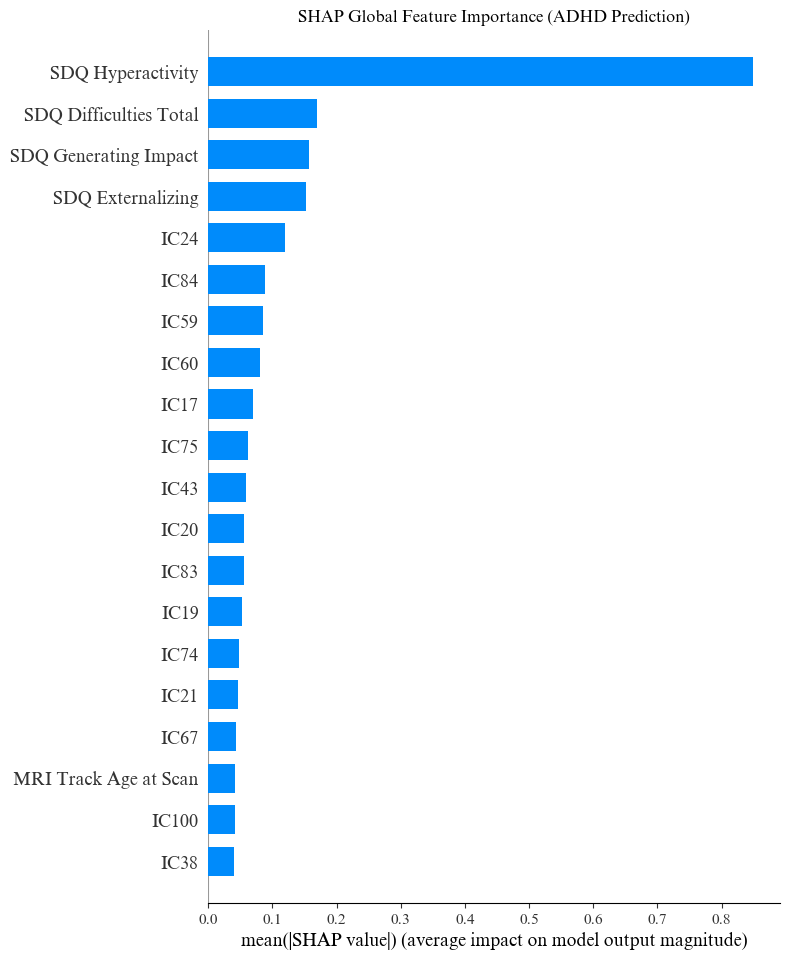

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


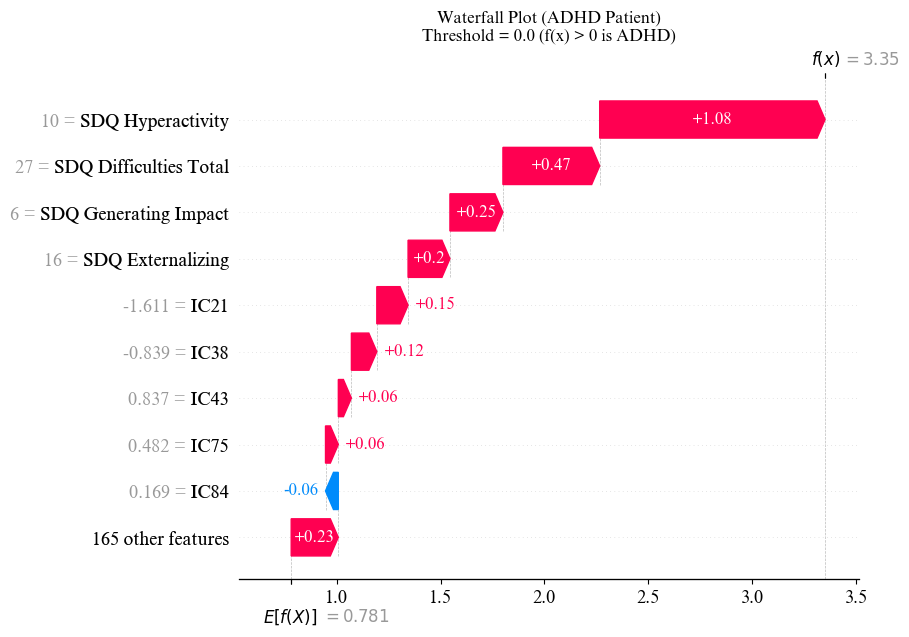

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


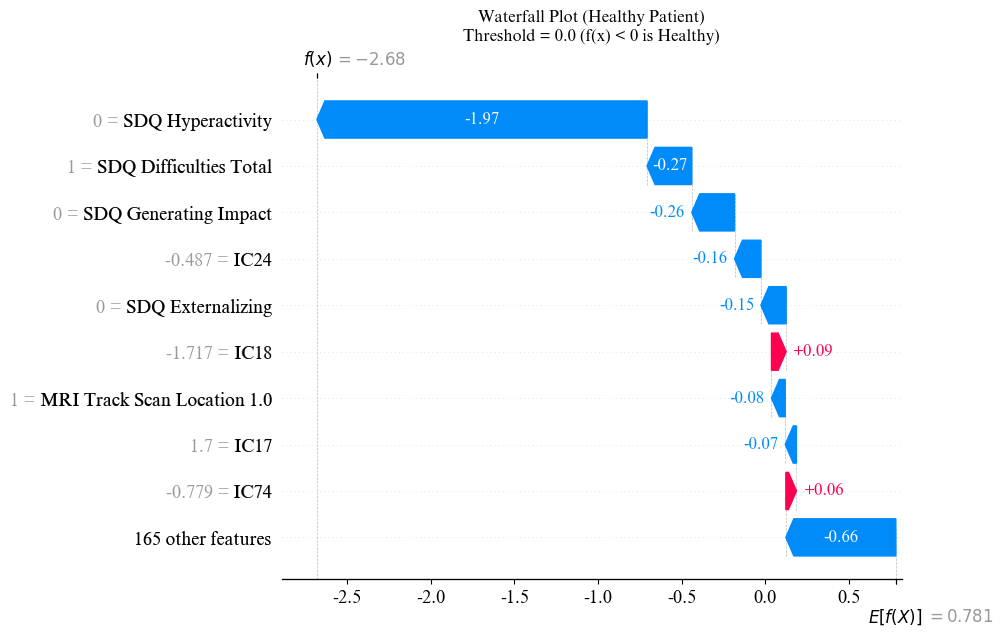

/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


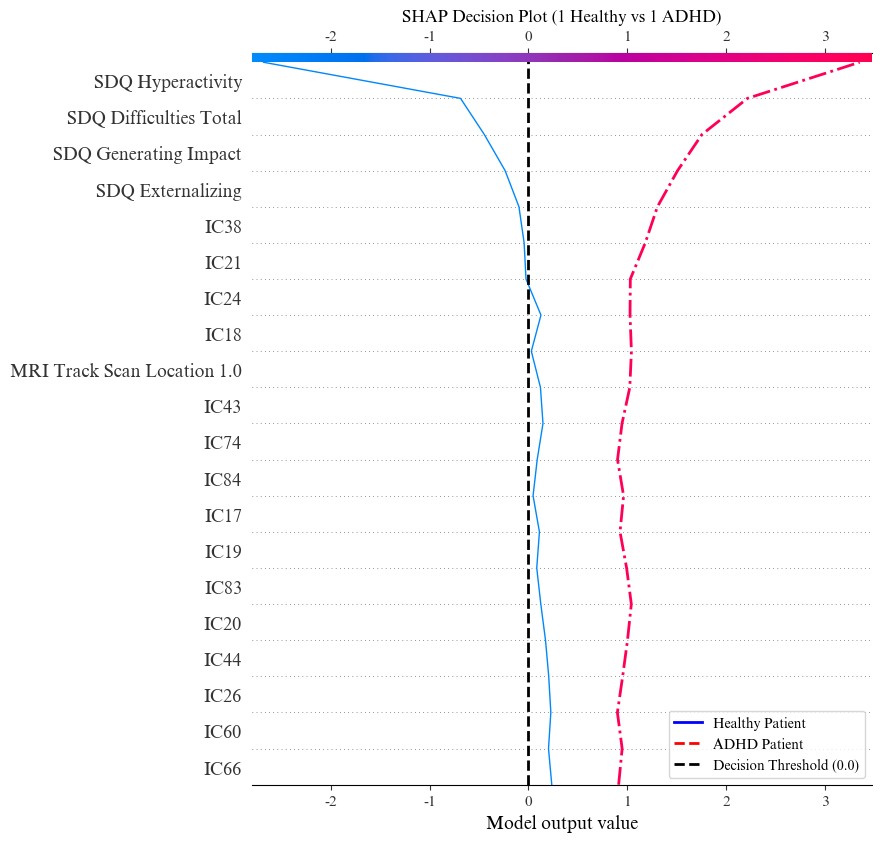

In [54]:
def fix_minus_sign(fig_or_ax=None):

    if fig_or_ax is None:
        fig_or_ax = plt.gcf()

    for ax in fig_or_ax.axes:

        for text in ax.texts:
            old_text = text.get_text()
            if '\u2212' in old_text:
                text.set_text(old_text.replace('\u2212', '-'))


        labels = [l.get_text().replace('\u2212', '-') for l in ax.get_yticklabels()]
        if any(labels):
            ax.set_yticklabels(labels)

        labels = [l.get_text().replace('\u2212', '-') for l in ax.get_xticklabels()]
        if any(labels):
            ax.set_xticklabels(labels)


adhd_candidates = np.where((preds_log_odds_adhd > 0) & (y_test_arr_adhd == 1))[0]
adhd_idx = adhd_candidates[np.argmax(preds_log_odds_adhd[adhd_candidates])] if len(adhd_candidates) > 0 else np.argmax(preds_log_odds_adhd)

healthy_candidates = np.where((preds_log_odds_adhd < 0) & (y_test_arr_adhd == 0))[0]
healthy_idx = healthy_candidates[np.argmin(preds_log_odds_adhd[healthy_candidates])] if len(healthy_candidates) > 0 else np.argmin(preds_log_odds_adhd)

# -------------------------
# 1. Global Importance
# -------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_adhd, X_test_adhd, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (ADHD Prediction)", fontweight='bold')
fix_minus_sign()
plt.show()

# -------------------------
# 2. Waterfall (ADHD Patient)
# -------------------------
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values_obj_adhd[adhd_idx], show=False)
plt.title(f"Waterfall Plot (ADHD Patient)\nThreshold = 0.0 (f(x) > 0 is ADHD)", fontweight='bold')
fix_minus_sign()
plt.show()

# -------------------------
# 3. Waterfall (Healthy Patient)
# -------------------------
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values_obj_adhd[healthy_idx], show=False)
plt.title(f"Waterfall Plot (Healthy Patient)\nThreshold = 0.0 (f(x) < 0 is Healthy)", fontweight='bold')
fix_minus_sign()
plt.show()

# -------------------------
# 4. Decision Plot
# -------------------------
plt.figure(figsize=(10, 8))
selected_indices_adhd = [healthy_idx, adhd_idx]
shap.decision_plot(
    explainer_adhd.expected_value,
    shap_values_adhd[selected_indices_adhd],
    X_test_adhd.iloc[selected_indices_adhd],
    highlight=[1],
    show=False
)
plt.title("SHAP Decision Plot (1 Healthy vs 1 ADHD)", fontweight='bold')

ax = plt.gca()
for line in list(ax.lines):
    xdata = list(line.get_xdata())
    is_vertical = len(xdata) == 2 and abs(xdata[0] - xdata[1]) < 1e-12
    color = line.get_color()
    if is_vertical and color not in ("black", "#000000", "k"):
        line.remove()

custom_lines = [
    Line2D([0], [0], color='blue', lw=2, label='Healthy Patient'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='ADHD Patient'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Decision Threshold (0.0)')
]
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.legend(handles=custom_lines, loc='lower right')

fix_minus_sign()
plt.show()

## Section B: Gender (Sex_F) Prediction (SHAP)

### 5. Load Data for Gender Prediction

In [56]:
print("Loading data for Gender Prediction...")
y_gender_list = []
X_list_gender = []

for pid in patient_ids:
    try:
        cat_row = cat_df[cat_df["participant_id"] == pid]
        quant_row = quant_df[quant_df["participant_id"] == pid]
        conn_row = conn_df[conn_df["participant_id"] == pid]

        if len(cat_row) == 0 or len(quant_row) == 0 or len(conn_row) == 0:
            continue

        cat_data = cat_row.drop(columns=drop_cols_cat, errors='ignore').values.flatten()
        quant_data = quant_row.drop(columns=["participant_id"], errors='ignore').values.flatten()
        conn_data = conn_row.drop(columns=["participant_id"], errors='ignore').values.flatten()

        sex_val = labels_df[labels_df["participant_id"] == pid]["Sex_F"].values[0]

        combined_features = np.concatenate([cat_data, quant_data, conn_data])
        X_list_gender.append(combined_features)
        y_gender_list.append(sex_val)
    except IndexError:
        continue

X_features_only_gender = pd.DataFrame(X_list_gender, columns=feature_names)
y_gender = np.array(y_gender_list)

X_train_gender, X_test_gender, y_train_gender, y_test_gender = train_test_split(
    X_features_only_gender, y_gender, test_size=0.3, random_state=42
)
print("Gender data ready! Feature names are clean.")

Loading data for Gender Prediction...
Gender data ready! Feature names are clean.


### 6. Train XGBoost Model & Plot for Gender

Training Optimized XGBoost Model for Gender...


/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


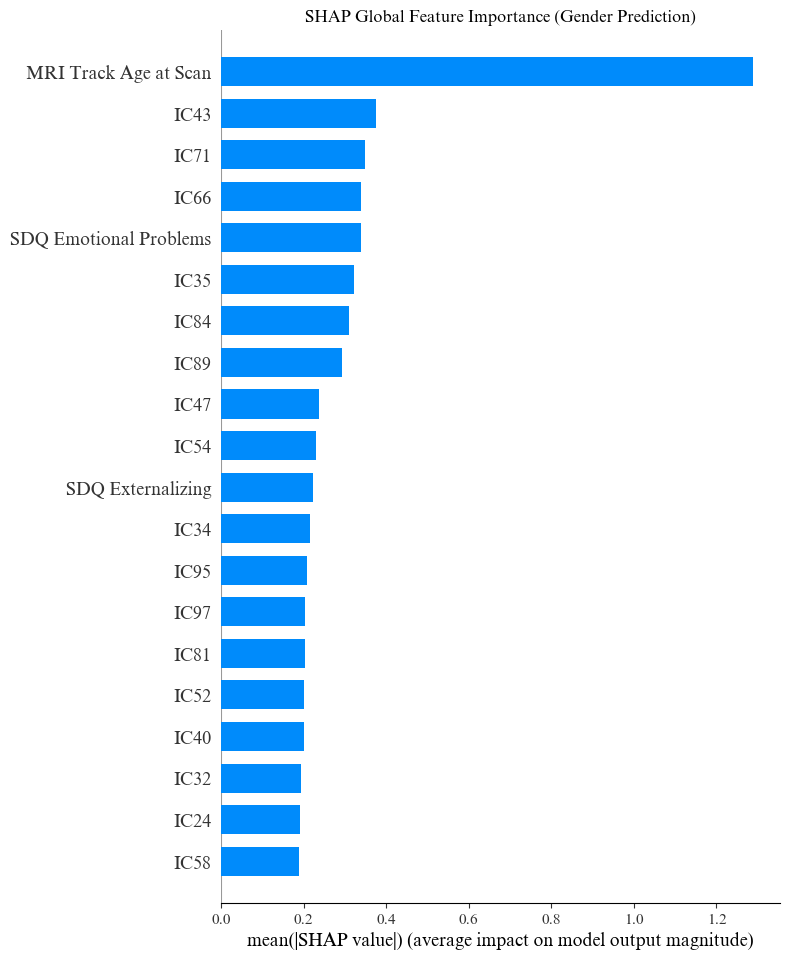

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


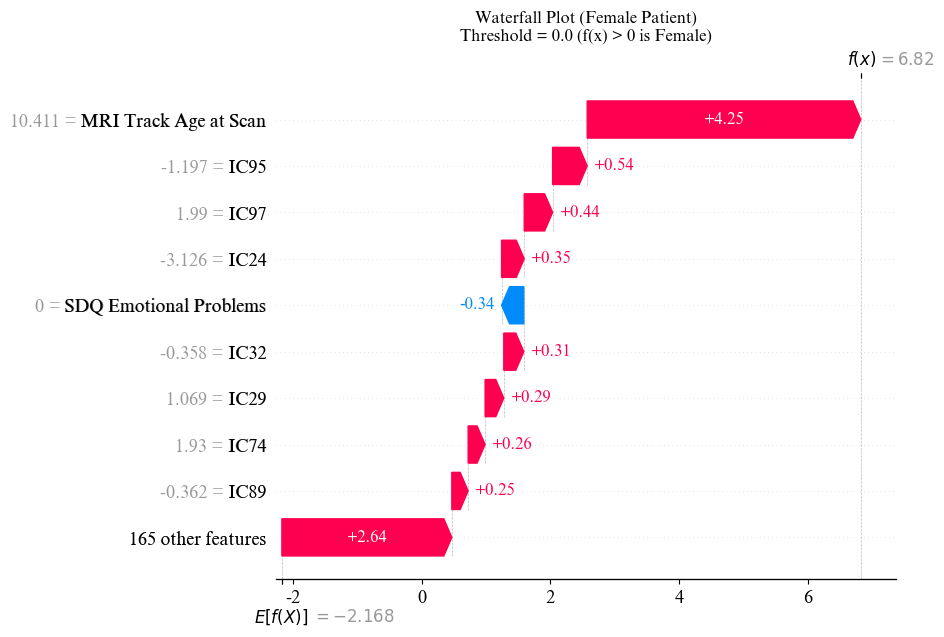

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


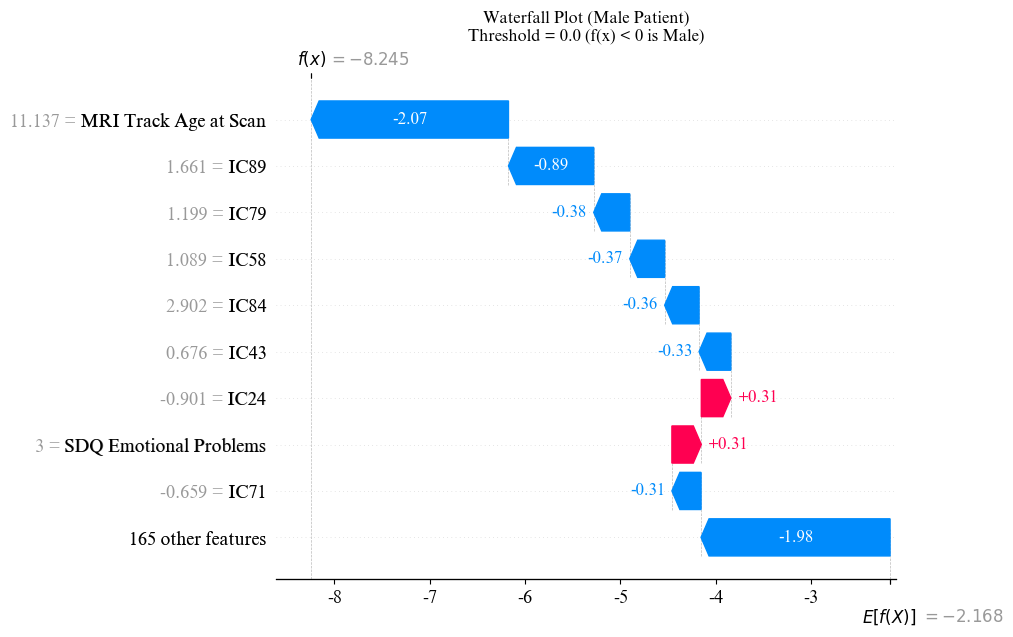

/tmp/ipykernel_8071/449890557.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


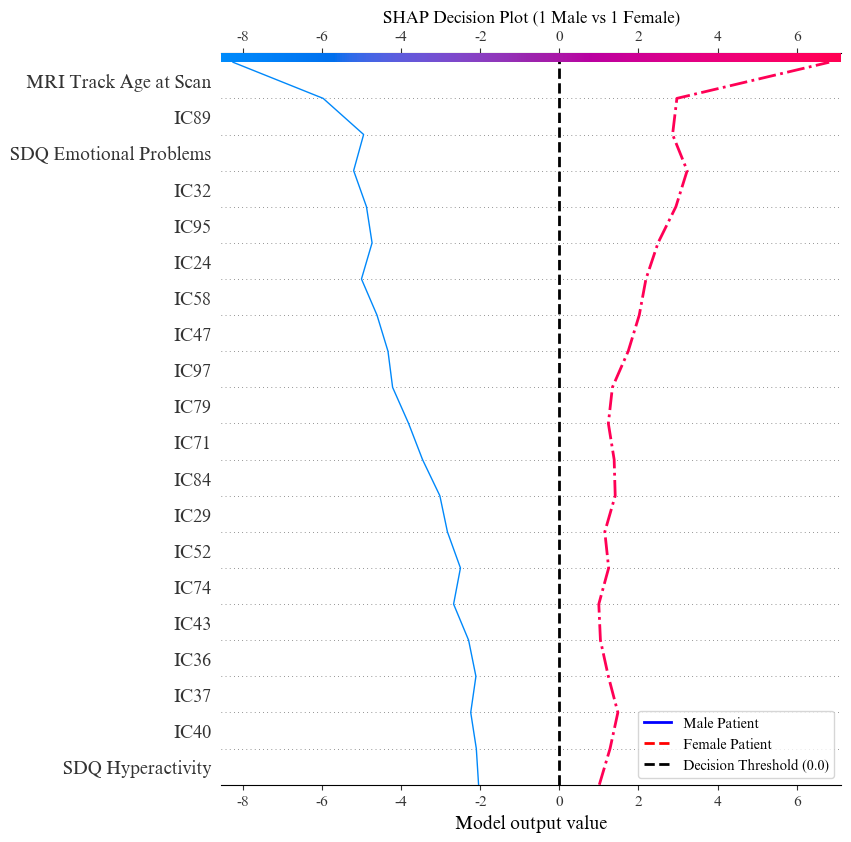

--- Gender Prediction SHAP Analysis Complete ---


In [57]:
# ==========================================
# 6. Train XGBoost Model & Plot for Gender
# ==========================================
print("Training Optimized XGBoost Model for Gender...")
model_gender = XGBClassifier(
    subsample=1.0,
    n_estimators=500,
    max_depth=7,
    learning_rate=0.1,
    colsample_bytree=0.8,
    random_state=42
)
model_gender.fit(X_train_gender, y_train_gender)

explainer_gender = shap.TreeExplainer(model_gender)
shap_values_gender = explainer_gender.shap_values(X_test_gender)
explainer_obj_gender = shap.Explainer(model_gender, X_train_gender)
shap_values_obj_gender = explainer_obj_gender(X_test_gender)

preds_log_odds_gender = model_gender.predict(X_test_gender, output_margin=True)
y_test_arr_gender = y_test_gender

female_candidates = np.where((preds_log_odds_gender > 0) & (y_test_arr_gender == 1))[0]
female_idx = female_candidates[np.argmax(preds_log_odds_gender[female_candidates])] if len(female_candidates) > 0 else np.argmax(preds_log_odds_gender)

male_candidates = np.where((preds_log_odds_gender < 0) & (y_test_arr_gender == 0))[0]
male_idx = male_candidates[np.argmin(preds_log_odds_gender[male_candidates])] if len(male_candidates) > 0 else np.argmin(preds_log_odds_gender)

# -------------------------
# Plotting
# -------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_gender, X_test_gender, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Gender Prediction)", fontweight='bold')
fix_minus_sign()
plt.show()

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values_obj_gender[female_idx], show=False)
plt.title(f"Waterfall Plot (Female Patient)\nThreshold = 0.0 (f(x) > 0 is Female)", fontweight='bold')
fix_minus_sign()
plt.show()

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values_obj_gender[male_idx], show=False)
plt.title(f"Waterfall Plot (Male Patient)\nThreshold = 0.0 (f(x) < 0 is Male)", fontweight='bold')
fix_minus_sign()
plt.show()

plt.figure(figsize=(10, 8))
selected_indices_gender = [male_idx, female_idx]
shap.decision_plot(
    explainer_gender.expected_value,
    shap_values_gender[selected_indices_gender],
    X_test_gender.iloc[selected_indices_gender],
    highlight=[1],
    show=False
)
plt.title("SHAP Decision Plot (1 Male vs 1 Female)", fontweight='bold')


ax = plt.gca()
for line in list(ax.lines):
    xdata = list(line.get_xdata())
    # 识别垂直线
    is_vertical = len(xdata) == 2 and abs(xdata[0] - xdata[1]) < 1e-12
    color = line.get_color()

    if is_vertical and color not in ("black", "#000000", "k"):
        line.remove()

custom_lines_gender = [
    Line2D([0], [0], color='blue', lw=2, label='Male Patient'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Female Patient'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Decision Threshold (0.0)')
]
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.legend(handles=custom_lines_gender, loc='lower right')

fix_minus_sign()
plt.show()
print("--- Gender Prediction SHAP Analysis Complete ---")